
Name: Mohammad Abdulelah Okleh Faris

SID:  160653

...................................................

Report:
Understanding the health indicators of diabetes:

Diabetes is a common chronic health condition that affects millions of people around the world.

Understanding health indicators associated with diabetes can aid early detection, management, and prevention efforts.

In this report, I analyze a data set containing various health indicators related to diabetes that were collected previously. 

First, I applied the OneHotEncoded algorithm to all the features such as BMI, General Health, Mental Health, Physical Health, and Age, where 0 equals the range of 0 to 6 and 1 equals the range from 6 to 14, education where 0 equals the range from 0 to 4 and 1 equals the range from 4 to 7, and finally the Income where 0 equals the range from 0 to 6 and 1 equals the range from 6 to 9.

Next, I converted the data set into a true/fulse data set, and I extracted association rules using the Apriori algorithm to determine the relationships between various health indicators and diabetes diagnosis.

Apriori's algorithm identified frequent item sets, which are sets of health indicators that frequently occur together in the data set for which the support is higher than 0.3, and found the length for each item set. These item sets provide insight into patterns of co-occurrence between variables.

From the sets of frequent items, I created association rules to capture relationships between health indicators and a diabetes diagnosis for confidence that was higher than 0.95 as I found it to be the most appropriate number that could be determined to find the best associations. These rules consist of antecedents and consequences, where antecedents refer to a set of health indicators, and consequences indicate the probability of being diagnosed with diabetes based on those indicators.

I also chose correlations in which the Lift value was higher than 1, because if it was, this would mean that this relationship strongly might be useful.
Then I adjusted the support value to 0.6, as I found that it gives stronger correlations.

I also visualized the data and found that there are very strong correlations centered at a very high value of Confidence and distributed around a relatively wide range of the value of support. It is also noticeable that there is a gap at Confidence = 0.98.

After analyzing the dataset and creating association rules, several insights were obtained:

Symptoms associated with diabetes: Some symptoms such as High Cholesterol, High blood pressure, and mental health have been found to be strongly associated with a diagnosis of diabetes. This suggests that individuals with these symptoms may have a greater likelihood of developing diabetes.

148
Rule: HighChol -> Diabetes_012
Support: 0.63
Confidence: 0.96
Lift: 1.00

141
Rule: HighBP -> Diabetes_012
Support: 0.71
Confidence: 0.96
Lift: 1.00

90
Rule: MentHlth_5less -> Diabetes_012
Support: 0.70
Confidence: 0.97
Lift: 1.01

Health behaviors and risk factors: In addition, some health behaviors and risk factors, such as physical inactivity and poor nutrition, have been found to be associated with a diagnosis of diabetes. This underscores the importance of lifestyle modifications and preventive measures in managing and reducing the risk of diabetes.

152
Rule: Diabetes_012 -> AnyHealthcare
Support: 0.65
Confidence: 0.96
Lift: 1.00

142
Rule: Veggies -> Diabetes_012
Support: 0.73
Confidence: 0.96
Lift: 1.00

138
Rule: PhysHlth_5less -> Diabetes_012
Support: 0.64
Confidence: 0.96
Lift: 1.00

Demographic factors: Analysis of demographic factors revealed potential disparities in diabetes diagnosis based on age not sex. Further investigation of these factors could provide valuable insights for targeted interventions and health care policies aimed at reducing the prevalence of diabetes and improving health outcomes.

108
Rule: Age -> Diabetes_012
Support: 0.85
Confidence: 0.97
Lift: 1.01




vvv THE CODE vvv

In [235]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


In [236]:
df = pd.read_csv('/kaggle/input/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv')

In [237]:
df.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


BMI Preprocessing

In [238]:
bmi_categories = {
    (float('-inf'), 18.5): 'Underweight',
    (18.5, 25): 'Normal',
    (25, 30): 'Overweight',
    (30, float('inf')): 'Obese'
}

df['BMI_Category'] = pd.cut(df['BMI'], bins=[float('-inf'), 18.5, 25, 30, float('inf')],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

df['BMI'] = df['BMI_Category']

df.drop('BMI_Category', axis = 1, inplace = True)

df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,Obese,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,Normal,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,Overweight,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,Overweight,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,Normal,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [239]:
from sklearn.preprocessing import OneHotEncoder
encode = OneHotEncoder(categories=[['Underweight', 'Normal', 'Overweight', 'Obese']])
encoded_df = pd.DataFrame(encode.fit_transform(df[['BMI']]).toarray())
encoded_df.columns = ['isUnderweight', 'isNormal', 'isOverweight', 'isObese']
df = df.join(encoded_df)
df.drop("BMI", axis=1, inplace=True)
df.head()

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension

,Diabetes_012,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Income,isUnderweight,isNormal,isOverweight,isObese
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,15.0,1.0,0.0,9.0,4.0,3.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,7.0,6.0,1.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,30.0,1.0,0.0,9.0,4.0,8.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,11.0,3.0,6.0,0.0,0.0,1.0,0.0
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,11.0,5.0,4.0,0.0,1.0,0.0,0.0


GenHlth Preprocessing

In [240]:
print(df['GenHlth'].value_counts())

GenHlth
2.0    89084
3.0    75646
1.0    45299
4.0    31570
5.0    12081
Name: count, dtype: int64


In [241]:
encode = OneHotEncoder(categories=[[1, 2, 3, 4, 5]])
encoded_df = pd.DataFrame(encode.fit_transform(df[['GenHlth']]).toarray())
encoded_df.columns = ['GenHlth_1', 'GenHlth_2', 'GenHlth_3', 'GenHlth_4', 'GenHlth_5']
df = df.join(encoded_df)
df.drop("GenHlth", axis=1, inplace=True)
df.head()

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension

,Diabetes_012,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,Income,isUnderweight,isNormal,isOverweight,isObese,GenHlth_1,GenHlth_2,GenHlth_3,GenHlth_4,GenHlth_5
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,6.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


MentHlth Preprocessing

In [242]:
print(df['MentHlth'].value_counts())

MentHlth
0.0     175680
2.0      13054
30.0     12088
5.0       9030
1.0       8538
3.0       7381
10.0      6373
15.0      5505
4.0       3789
20.0      3364
7.0       3100
25.0      1188
14.0      1167
6.0        988
8.0        639
12.0       398
28.0       327
21.0       227
29.0       158
18.0        97
9.0         91
16.0        88
27.0        79
22.0        63
17.0        54
26.0        45
11.0        41
13.0        41
23.0        38
24.0        33
19.0        16
Name: count, dtype: int64


In [243]:
mentHlth_categories = {
    (float('-inf'), 6): 'MentHlth_5less',
    (6, 16): 'MentHlth_5-15',
    (16, 31): 'MentHlth_15more'
}

df['MentHlth_Category'] = pd.cut(df['MentHlth'], bins=[float('-inf'), 6, 16, 31],
                            labels=['MentHlth_5less', 'MentHlth_5-15', 'MentHlth_15more'])

df['MentHlth'] = df['MentHlth_Category']

df.drop('MentHlth', axis = 1, inplace = True)

df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,isUnderweight,isNormal,isOverweight,isObese,GenHlth_1,GenHlth_2,GenHlth_3,GenHlth_4,GenHlth_5,MentHlth_Category
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,MentHlth_15more
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MentHlth_5less
2,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,MentHlth_15more
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,MentHlth_5less
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,MentHlth_5less


In [244]:
encode = OneHotEncoder(categories=[['MentHlth_5less', 'MentHlth_5-15', 'MentHlth_15more']])
encoded_df = pd.DataFrame(encode.fit_transform(df[['MentHlth_Category']]).toarray())
encoded_df.columns = ['MentHlth_5less', 'MentHlth_5-15', 'MentHlth_15more']
df = df.join(encoded_df)
df.drop("MentHlth_Category", axis=1, inplace=True)
df.head()

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension

,Diabetes_012,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,isOverweight,isObese,GenHlth_1,GenHlth_2,GenHlth_3,GenHlth_4,GenHlth_5,MentHlth_5less,MentHlth_5-15,MentHlth_15more
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


PhysHlth Preprocessing

In [245]:
print(df['PhysHlth'].value_counts())

PhysHlth
0.0     160052
30.0     19400
2.0      14764
1.0      11388
3.0       8495
5.0       7622
10.0      5595
15.0      4916
4.0       4542
7.0       4538
20.0      3273
14.0      2587
25.0      1336
6.0       1330
8.0        809
21.0       663
12.0       578
28.0       522
29.0       215
9.0        179
18.0       152
16.0       112
27.0        99
17.0        96
24.0        72
22.0        70
26.0        69
13.0        68
11.0        60
23.0        56
19.0        22
Name: count, dtype: int64


In [246]:
physHlth_categories = {
    (float('-inf'), 6): 'PhysHlth_5less',
    (6, 16): 'PhysHlth_5-15',
    (16, 31): 'PhysHlth_15more'
}

df['PhysHlth_Category'] = pd.cut(df['PhysHlth'], bins=[float('-inf'), 6, 16, 31],
                            labels=['PhysHlth_5less', 'PhysHlth_5-15', 'PhysHlth_15more'])

df['PhysHlth'] = df['PhysHlth_Category']

df.drop('PhysHlth_Category', axis = 1, inplace = True)



In [247]:
df['PhysHlth']

0           PhysHlth_5-15
1          PhysHlth_5less
2         PhysHlth_15more
3          PhysHlth_5less
4          PhysHlth_5less
               ...       
253675     PhysHlth_5less
253676     PhysHlth_5less
253677     PhysHlth_5less
253678     PhysHlth_5less
253679     PhysHlth_5less
Name: PhysHlth, Length: 253680, dtype: category
Categories (3, object): ['PhysHlth_5less' < 'PhysHlth_5-15' < 'PhysHlth_15more']

In [248]:
encode = OneHotEncoder(categories=[['PhysHlth_5less', 'PhysHlth_5-15', 'PhysHlth_15more']])
encoded_df = pd.DataFrame(encode.fit_transform(df[['PhysHlth']]).toarray())
encoded_df.columns = ['PhysHlth_5less', 'PhysHlth_5-15', 'PhysHlth_15more']
df = df.join(encoded_df)
df.drop("PhysHlth", axis=1, inplace=True)
df.head()

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension

,Diabetes_012,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth_2,GenHlth_3,GenHlth_4,GenHlth_5,MentHlth_5less,MentHlth_5-15,MentHlth_15more,PhysHlth_5less,PhysHlth_5-15,PhysHlth_15more
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


Age Preprocessing

In [249]:
print(df['Age'].value_counts())

Age
9.0     33244
10.0    32194
8.0     30832
7.0     26314
11.0    23533
6.0     19819
13.0    17363
5.0     16157
12.0    15980
4.0     13823
3.0     11123
2.0      7598
1.0      5700
Name: count, dtype: int64


In [250]:
Age_categories = {
    (float('-inf'), 6): 0,
    (6, 14): 1
}

df['Age_Category'] = pd.cut(df['Age'], bins=[float('-inf'), 6, 14],
                            labels=[0, 1])

df['Age'] = df['Age_Category']

df.drop('Age_Category', axis = 1, inplace = True)


In [251]:
df['Age']

0         1
1         1
2         1
3         1
4         1
         ..
253675    0
253676    1
253677    0
253678    1
253679    1
Name: Age, Length: 253680, dtype: category
Categories (2, int64): [0 < 1]

Education Preprocessing

In [252]:
print(df['Education'].value_counts())

Education
6.0    107325
5.0     69910
4.0     62750
3.0      9478
2.0      4043
1.0       174
Name: count, dtype: int64


In [253]:
Education_categories = {
    (float('-inf'), 4): 0,
    (4, 7): 1
}

df['Education_Category'] = pd.cut(df['Education'], bins=[float('-inf'), 4, 7],
                            labels=[0, 1])

df['Education'] = df['Education_Category']

df.drop('Education_Category', axis = 1, inplace = True)


In [254]:
df['Education']

0         0
1         1
2         0
3         0
4         1
         ..
253675    1
253676    0
253677    1
253678    1
253679    1
Name: Education, Length: 253680, dtype: category
Categories (2, int64): [0 < 1]

Income Preprocessing

In [255]:
print(df['Income'].value_counts())

Income
8.0    90385
7.0    43219
6.0    36470
5.0    25883
4.0    20135
3.0    15994
2.0    11783
1.0     9811
Name: count, dtype: int64


In [256]:
Income_categories = {
    (float('-inf'), 6): 0,
    (6, 9): 1
}

df['Income_Category'] = pd.cut(df['Income'], bins=[float('-inf'), 4, 9],
                            labels=[0, 1])

df['Income'] = df['Income_Category']

df.drop('Income_Category', axis = 1, inplace = True)


In [257]:
df['Income']

0         0
1         0
2         1
3         1
4         0
         ..
253675    1
253676    0
253677    0
253678    0
253679    0
Name: Income, Length: 253680, dtype: category
Categories (2, int64): [0 < 1]

Apriori Algo - Assosiation Rules 

In [258]:
df=df.astype(bool)
df.head(100)

,Diabetes_012,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth_2,GenHlth_3,GenHlth_4,GenHlth_5,MentHlth_5less,MentHlth_5-15,MentHlth_15more,PhysHlth_5less,PhysHlth_5-15,PhysHlth_15more
0,False,True,True,True,True,False,False,False,False,True,...,False,False,False,True,False,False,True,False,True,False
1,False,False,False,False,True,False,False,True,False,False,...,False,True,False,False,True,False,False,True,False,False
2,False,True,True,True,False,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,True
3,False,True,False,True,False,False,False,True,True,True,...,True,False,False,False,True,False,False,True,False,False
4,False,True,True,True,False,False,False,True,True,True,...,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,True,True,True,True,True,False,True,False,True,True,...,False,False,False,True,False,True,False,False,False,True
96,True,False,False,True,False,False,False,True,False,True,...,False,False,True,False,True,False,False,True,False,False
97,False,True,False,True,False,False,False,True,True,True,...,False,True,False,False,True,False,False,True,False,False
98,False,True,True,True,False,False,False,False,True,True,...,True,False,False,False,True,False,False,True,False,False


In [259]:
df_diabetes_true = df[df['Diabetes_012'] == True].copy()

df_diabetes_true

,Diabetes_012,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth_2,GenHlth_3,GenHlth_4,GenHlth_5,MentHlth_5less,MentHlth_5-15,MentHlth_15more,PhysHlth_5less,PhysHlth_5-15,PhysHlth_15more
8,True,True,True,True,True,False,True,False,True,True,...,False,False,False,True,False,False,True,False,False,True
10,True,False,False,True,True,False,False,True,True,True,...,False,True,False,False,True,False,False,True,False,False
13,True,True,True,True,False,False,False,False,False,True,...,False,False,True,False,True,False,False,True,False,False
17,True,False,False,True,True,False,False,True,False,False,...,True,False,False,False,True,False,False,True,False,False
23,True,True,False,True,False,False,False,True,True,True,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253666,True,True,False,True,False,False,False,False,True,True,...,False,True,False,False,True,False,False,False,True,False
253668,True,False,True,True,True,False,True,False,True,True,...,True,False,False,False,True,False,False,True,False,False
253670,True,True,True,True,False,False,True,False,True,False,...,False,False,False,True,False,True,False,True,False,False
253676,True,True,True,True,False,False,False,False,False,False,...,False,False,True,False,True,False,False,True,False,False


In [260]:
from mlxtend.frequent_patterns import apriori
frequent_itemsets=apriori(df_diabetes_true, min_support=0.3, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets.sort_values("support", ascending = False)

frequent_itemsets

,support,itemsets,length
0,1.000000,(Diabetes_012),1
1,0.738350,(HighBP),1
2,0.664407,(HighChol),1
3,0.992421,(CholCheck),1
4,0.515271,(Smoker),1
...,...,...,...
2020,0.303600,"(AnyHealthcare, Age, MentHlth_5less, PhysHlth_...",7
2021,0.308703,"(AnyHealthcare, Age, MentHlth_5less, PhysHlth_...",7
2022,0.301173,"(AnyHealthcare, Age, MentHlth_5less, PhysHlth_...",8
2023,0.303600,"(AnyHealthcare, Age, MentHlth_5less, PhysHlth_...",8


In [261]:
from mlxtend.frequent_patterns import association_rules

assrls = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.95)

assrls

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(HighBP),(Diabetes_012),0.738350,1.000000,0.738350,1.000000,1.000000,0.000000,inf,0.000000
1,(HighChol),(Diabetes_012),0.664407,1.000000,0.664407,1.000000,1.000000,0.000000,inf,0.000000
2,(Diabetes_012),(CholCheck),1.000000,0.992421,0.992421,0.992421,1.000000,0.000000,1.000000,0.000000
3,(CholCheck),(Diabetes_012),0.992421,1.000000,0.992421,1.000000,1.000000,0.000000,inf,0.000000
4,(Smoker),(Diabetes_012),0.515271,1.000000,0.515271,1.000000,1.000000,0.000000,inf,0.000000
...,...,...,...,...,...,...,...,...,...,...
4673,"(Age, MentHlth_5less, PhysHlth_5less, Income, ...",(AnyHealthcare),0.314756,0.958076,0.308703,0.980768,1.023685,0.007142,2.179880,0.033764
4674,"(AnyHealthcare, Age, MentHlth_5less, PhysHlth_...","(Diabetes_012, CholCheck)",0.309703,0.992421,0.308703,0.996769,1.004382,0.001347,2.346001,0.006320
4675,"(Age, MentHlth_5less, PhysHlth_5less, Income, ...","(CholCheck, AnyHealthcare)",0.315857,0.952473,0.308703,0.977350,1.026119,0.007858,2.098348,0.037206
4676,"(Age, MentHlth_5less, PhysHlth_5less, Income, ...","(Diabetes_012, AnyHealthcare)",0.314756,0.958076,0.308703,0.980768,1.023685,0.007142,2.179880,0.033764


In [262]:
assrls = assrls[assrls.lift > 1].sort_values("confidence", ascending = False)
assrls = assrls[assrls.support > 0.6].sort_values("confidence", ascending = False)
assrls

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
2245,"(Age, Veggies, AnyHealthcare)","(Diabetes_012, CholCheck)",0.648248,0.992421,0.645396,0.995601,1.003205,0.002062,1.722974,0.009081
1343,"(Age, Veggies, AnyHealthcare)",(CholCheck),0.648248,0.992421,0.645396,0.995601,1.003205,0.002062,1.722974,0.009081
2242,"(Age, Veggies, Diabetes_012, AnyHealthcare)",(CholCheck),0.648248,0.992421,0.645396,0.995601,1.003205,0.002062,1.722974,0.009081
1643,"(HighBP, Age, AnyHealthcare)","(Diabetes_012, CholCheck)",0.651525,0.992421,0.648623,0.995546,1.003150,0.002036,1.701827,0.009010
1125,"(HighBP, Age, AnyHealthcare)",(CholCheck),0.651525,0.992421,0.648623,0.995546,1.003150,0.002036,1.701827,0.009010
...,...,...,...,...,...,...,...,...,...,...
802,(PhysHlth_5less),"(AnyHealthcare, Diabetes_012, CholCheck)",0.674738,0.952473,0.644120,0.954623,1.002258,0.001451,1.047387,0.006925
800,"(Diabetes_012, PhysHlth_5less)","(AnyHealthcare, CholCheck)",0.674738,0.952473,0.644120,0.954623,1.002258,0.001451,1.047387,0.006925
551,(HighChol),"(AnyHealthcare, Diabetes_012, CholCheck)",0.664407,0.952473,0.634140,0.954444,1.002070,0.001310,1.043284,0.006156
262,(HighChol),"(AnyHealthcare, CholCheck)",0.664407,0.952473,0.634140,0.954444,1.002070,0.001310,1.043284,0.006156


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


<Axes: xlabel='support', ylabel='confidence'>

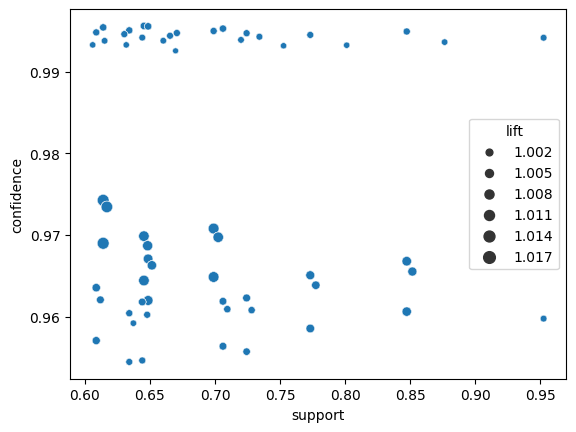

In [263]:
import seaborn as sns

sns.scatterplot(x = "support", y = "confidence", size = "lift", data = assrls)

In [264]:
i = 1
for index, row in assrls.sort_values("confidence", ascending = False).iterrows():
    fst_item = set(row['antecedents']).pop()
    snd_item = set(row['consequents']).pop()
    support = row['support']
    confidence = row['confidence']
    lift = row['lift']
    
    print(i)
    print(f"Rule: {fst_item} -> {snd_item}")
    print(f"Support: {support:.2f}")
    print(f"Confidence: {confidence:.2f}")
    print(f"Lift: {lift:.2f}")
    print("=====================================")
    i = i + 1
   
    if set(row['antecedents']) == 0:
        break

1
Rule: Age -> Diabetes_012
Support: 0.65
Confidence: 1.00
Lift: 1.00
2
Rule: Age -> CholCheck
Support: 0.65
Confidence: 1.00
Lift: 1.00
3
Rule: Age -> CholCheck
Support: 0.65
Confidence: 1.00
Lift: 1.00
4
Rule: HighBP -> Diabetes_012
Support: 0.65
Confidence: 1.00
Lift: 1.00
5
Rule: HighBP -> CholCheck
Support: 0.65
Confidence: 1.00
Lift: 1.00
6
Rule: HighBP -> CholCheck
Support: 0.65
Confidence: 1.00
Lift: 1.00
7
Rule: Income -> CholCheck
Support: 0.61
Confidence: 1.00
Lift: 1.00
8
Rule: Income -> Diabetes_012
Support: 0.61
Confidence: 1.00
Lift: 1.00
9
Rule: Income -> CholCheck
Support: 0.61
Confidence: 1.00
Lift: 1.00
10
Rule: HighBP -> Diabetes_012
Support: 0.71
Confidence: 1.00
Lift: 1.00
11
Rule: HighBP -> CholCheck
Support: 0.71
Confidence: 1.00
Lift: 1.00
12
Rule: HighBP -> CholCheck
Support: 0.71
Confidence: 1.00
Lift: 1.00
13
Rule: HighChol -> Diabetes_012
Support: 0.63
Confidence: 1.00
Lift: 1.00
14
Rule: HighChol -> CholCheck
Support: 0.63
Confidence: 1.00
Lift: 1.00
15
Ru

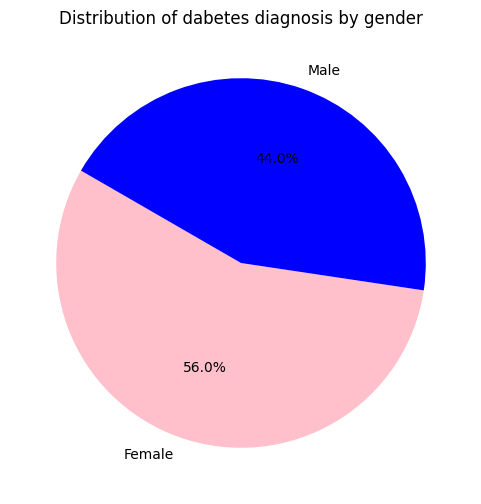

In [265]:
#Additional info
gender_dist = df['Sex'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_dist, labels=['Female', 'Male'], autopct='%1.1f%%', colors=['pink', 'blue'], startangle=150)
plt.title('Distribution of dabetes diagnosis by gender')
plt.show()